In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
from sklearn.manifold import TSNE
import umap
from torchvision import datasets, transforms
from sklearn.datasets import load_iris
from numpy import reshape
import seaborn as sns
import pandas as pd
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import normalized_mutual_info_score, silhouette_score
from sklearn.cluster import KMeans

/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
## Preparation for similarity method
torch.cuda.is_available()

True

# MNIST dataset TSNE fitting and visualizing

## 1. Data prepocessing

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

n=40000

x_train = torch.cat((mnist_train.data.float(), mnist_test.data.float()),0).to(torch.float32)[:n,]
y_train = torch.cat((mnist_train.targets, mnist_test.targets),0).to(torch.float32)[:n,]

del mnist_train
del mnist_test

x_train = x_train.view(x_train.shape[0], -1)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")

x_train shape: torch.Size([40000, 784])
y_train shape: torch.Size([40000])


In [5]:
x_new = x_train.T
del x_train
print(x_new.shape)
type(x_new)

torch.Size([784, 40000])


torch.Tensor

## 2. Function defined 

#### Y Approximation
*   n = 70000
*   k = 10
*   ny = 500

In [6]:
def gaussian_kernel(x, y, sigma=1000.0):
    beta = 1.0 / (2.0 * sigma ** 2)
    dist = torch.cdist(x.t(), y.t()) ** 2
    # print(dist.mean())
    kernel = torch.exp(-beta * dist)
    return kernel

def mmd_loss(x, y, sigma_list=[10.0, 20.0, 30.0, 50.0]):

    mmd_list = []
    for sigma in sigma_list:
      xx_kernel = gaussian_kernel(x, x, sigma)
      yy_kernel = gaussian_kernel(y, y, sigma)
      xy_kernel = gaussian_kernel(x, y, sigma)
      mmd = xx_kernel.mean() + yy_kernel.mean() - 2 * xy_kernel.mean()
      mmd_list.append(mmd)
    return max(mmd_list)

# 假设我们有 k 个数据集 X1 到 Xk
k = 10
n = x_new.shape[1]//k
m = x_new.shape[0]
ny = 500
batch_size = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
x_tensor = x_new/255
X = [x_tensor[:, i*n:(i+1)*n].to(device) for i in range(k)]

def approximate_Y(init_Y = torch.rand((m, ny), dtype=torch.float32, requires_grad=True, device=device), beta = 0.0, num_epochs = 500):
  
  Y = init_Y
  # print(Y)
  learning_rate = 1e-1
  # optimizer = torch.optim.SGD([Y], lr=learning_rate)
  optimizer = torch.optim.Adam([Y], lr=learning_rate)
  # optimizer = torch.optim.RMSprop([Y], lr=learning_rate)

  # 训练循环
  for epoch in range(num_epochs):

      total_loss = 0.0
      optimizer.zero_grad()
      total_grad = None

      for i in range(k):
          Xi = X[i]

          # mini_batch
          dataset = TensorDataset(Xi.t())
          data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

          for batch in data_loader:
            Xi_batch = batch[0].t()
            loss = mmd_loss(Xi_batch, Y)
            loss.backward()
            total_loss += loss.item()

            gradients = Y.grad
            std_grad = torch.std(gradients)
            noise = torch.randn_like(gradients) * std_grad * beta
            noisy_gradients = gradients + noise

            if total_grad is None:
              total_grad = noisy_gradients
            else:
              total_grad += noisy_gradients
            break # only use first mini-batch

          Y.grad.zero_()

      avg_grad = total_grad / k
      total_loss = total_loss / k

      with torch.no_grad():
          Y.grad = avg_grad
          Y.data=torch.clamp(Y.data, min=0, max=1)
          optimizer.step()
      if epoch== num_epochs-1:
          print('Epoch finished')

  return Y, total_loss

cuda


In [7]:
import matplotlib.pyplot as plt

def visualize_Y(Y):

    # figure
    for i in range(24):
        vector = Y[:, torch.randint(0,ny,(1,1))].cpu().detach().numpy()
        image = vector.reshape(28, 28)
        plt.subplot(3, 8, i+1)
        plt.imshow(image, cmap='gray', vmin=0, vmax=1)
        plt.title('28x28 Image')
    plt.show()

    # Y tsne visualization
    Y_numpy = Y.detach().cpu().numpy()
    # tsne = TSNE(n_components=2, verbose=1)
    # z = tsne.fit_transform(Y_numpy.T)
    reducer = umap.UMAP(n_components=2)
    z = reducer.fit_transform(Y_numpy.T)

    df = pd.DataFrame()
    df["y"] = 1
    df["comp-1"] = z[:,0]
    df["comp-2"] = z[:,1]

    sns.scatterplot(x="comp-1", y="comp-2",
                    data=df).set(title="Y UMAP projection")

#### TSNE result

In [8]:
def calculate_overlap_ratio(high_dim_data, low_dim_data, k):
    """
    high_dim_data: torch data (40000*784)
    low_dim_data: z(40000*2)
    """
    high_dim_data = high_dim_data.cpu().detach().numpy()

    # 在高维空间中找到每个点的 k 近邻
    nn_high = NearestNeighbors(n_neighbors=k+1).fit(high_dim_data)
    distances_high, indices_high = nn_high.kneighbors(high_dim_data)
    
    # 在低维空间中找到每个点的 k 近邻
    nn_low = NearestNeighbors(n_neighbors=k+1).fit(low_dim_data)
    distances_low, indices_low = nn_low.kneighbors(low_dim_data)
    
    overlap_ratios = []
    
    # 对于每个点，计算两个集合的重叠比例
    for i in range(len(high_dim_data)):
        A = set(indices_high[i][1:])  # 跳过自身
        B = set(indices_low[i][1:])   # 跳过自身
        overlap = len(A.intersection(B)) / k
        overlap_ratios.append(overlap)
    
    return np.mean(overlap_ratios)

In [9]:
def tsne_res(high_dim_data, distance, y_train=y_train, visualize=False):
  tsne = TSNE(n_components=2, verbose=0, metric="precomputed", init='random')
  z = tsne.fit_transform(distance)
  # reducer = umap.UMAP(n_components=2, metric='precomputed', init='random')
  # z = reducer.fit_transform(distance)

  if visualize == True:
    df = pd.DataFrame()
    df["y"] = y_train
    df["comp-1"] = z[:,0]
    df["comp-2"] = z[:,1]

    sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df).set(title="MNIST data UMAP projection")

#-------------------------------------------------------------------------
  X_tr, X_te, y_tr, y_te = train_test_split(z, y_train, test_size=0.3)
  k_values = 10

  knn_accuracies = {}

  result = [0, 0, 0]
  # [10-nn, NMI, overlap_10nn]

  # k-NN分类器
  k = k_values
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_tr, y_tr)
  accuracy = knn.score(X_te, y_te)
  result[0] = accuracy

  # for key,value in knn_accuracies.items():
  #     print(f'{key}-nn:/ {value}')

  # 使用kmeans聚类
  kmeans = KMeans(n_clusters=10, n_init=10)
  y_pred = kmeans.fit_predict(z)

  # 计算NMI
  nmi = normalized_mutual_info_score(y_train, y_pred)
  result[1] = nmi
  # print('NMI:', nmi)

  # # 计算轮廓系数
  # sc = silhouette_score(z, y_pred)
  # result[4] = sc
  # # print('SC:', sc)

  # 计算overlap
  # result[5] = calculate_overlap_ratio(high_dim_data, z, k=1)
  result[2] = calculate_overlap_ratio(high_dim_data, z, k=10)
  # result[7] = calculate_overlap_ratio(high_dim_data, z, k=50)

  return result, z

#### approxiamted TSNE
- estimate x dist from dist

In [10]:
def estimate_x_dist(shuffled_X_cat, Y):
  '''
  shuffled_X_cat
  Y: learned dist
  '''
  B = torch.cdist(Y.t(), shuffled_X_cat.t())
  A = torch.cdist(Y.t(), Y.t())
  # A = A + torch.eye(A.shape[0], device = device)*1e-5
  # B = Y.t() @ X_cat
  # A = Y.t() @ Y
  res = B.t() @ torch.linalg.inv(A) @ B
  res[torch.arange(res.size(0)), torch.arange(res.size(1))] = 0
  return res

In [11]:
def umap_res(high_dim_data, distance, y_train=y_train, visualize=False):
#   tsne = TSNE(n_components=2, verbose=0, metric="precomputed", init='random')
#   z = tsne.fit_transform(distance)
  reducer = umap.UMAP(n_components=2, metric='precomputed', init='random')
  z = reducer.fit_transform(distance)

  if visualize == True:
    df = pd.DataFrame()
    df["y"] = y_train
    df["comp-1"] = z[:,0]
    df["comp-2"] = z[:,1]

    sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df).set(title="MNIST data UMAP projection")

#-------------------------------------------------------------------------
  X_tr, X_te, y_tr, y_te = train_test_split(z, y_train, test_size=0.3)
  k_values = 10

  knn_accuracies = {}

  result = [0, 0, 0]
  # [10-nn, NMI, overlap_10nn]

  # k-NN分类器
  k = k_values
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_tr, y_tr)
  accuracy = knn.score(X_te, y_te)
  result[0] = accuracy

  # for key,value in knn_accuracies.items():
  #     print(f'{key}-nn:/ {value}')

  # 使用kmeans聚类
  kmeans = KMeans(n_clusters=10, n_init=10)
  y_pred = kmeans.fit_predict(z)

  # 计算NMI
  nmi = normalized_mutual_info_score(y_train, y_pred)
  result[1] = nmi
  # print('NMI:', nmi)

  # # 计算轮廓系数
  # sc = silhouette_score(z, y_pred)
  # result[4] = sc
  # # print('SC:', sc)

  # 计算overlap
  # result[5] = calculate_overlap_ratio(high_dim_data, z, k=1)
  result[2] = calculate_overlap_ratio(high_dim_data, z, k=10)
  # result[7] = calculate_overlap_ratio(high_dim_data, z, k=50)

  return result, z

## 3. Experiments

In [12]:
X_cat = torch.cat(X, dim=1)
#-----------------
cols = X_cat.size(1)

perm = torch.randperm(cols)
shuffled_X_cat = X_cat[:, perm]
y_train = y_train[perm]

### approximate with beta = 0.0 (average 5 experiments)

Epoch finished
res: [0.8711666666666666, 0.5834444946643129, 0.1885875]
loss: 0.5306558728218078
finish
Epoch finished
res: [0.903, 0.6390240233193228, 0.1880975]
loss: 0.22028036117553712
finish
Epoch finished
res: [0.9328333333333333, 0.6830145029182166, 0.24976500000000001]
loss: 0.005279314517974853
finish
Epoch finished
res: [0.9461666666666667, 0.7430166828670041, 0.31995750000000006]
loss: 0.002091860771179199
finish
Epoch finished
res: [0.9495833333333333, 0.7342358327979062, 0.33952]
loss: 0.0020450592041015626
finish
tsne
NMI: [0.6390240233193228, 0.6830145029182166, 0.7430166828670041, 0.7342358327979062]
CA_10nn: [0.903, 0.9328333333333333, 0.9461666666666667, 0.9495833333333333]
NPA_10nn [0.1880975, 0.24976500000000001, 0.31995750000000006, 0.33952]
loss_list [0.5306558728218078, 0.22028036117553712, 0.005279314517974853, 0.002091860771179199, 0.0020450592041015626]


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1858: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


Epoch finished
res: [0.75725, 0.5602728660654444, 0.0458725]
loss: 0.5373742341995239
finish
Epoch finished


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1858: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


res: [0.8755833333333334, 0.675530474377662, 0.06009249999999999]
loss: 0.22066792845726013
finish
Epoch finished


...

res: [0.9171666666666667, 0.6954098161133465, 0.0785475]
loss: 0.005155491828918457
finish
Epoch finished


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1858: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


res: [0.9395, 0.7844606636554485, 0.1052625]
loss: 0.0020917773246765135
finish
Epoch finished


/home/MaXX/.conda/envs/fan_research/lib/python3.8/site-packages/umap/umap_.py:1858: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


res: [0.9455, 0.7990556178675685, 0.1123125]
loss: 0.0020137310028076174
finish
umap
NMI: [0.675530474377662, 0.6954098161133465, 0.7844606636554485, 0.7990556178675685]
CA_10nn: [0.8755833333333334, 0.9171666666666667, 0.9395, 0.9455]
NPA_10nn [0.06009249999999999, 0.0785475, 0.1052625, 0.1123125]
loss_list [0.5373742341995239, 0.22066792845726013, 0.005155491828918457, 0.0020917773246765135, 0.0020137310028076174]


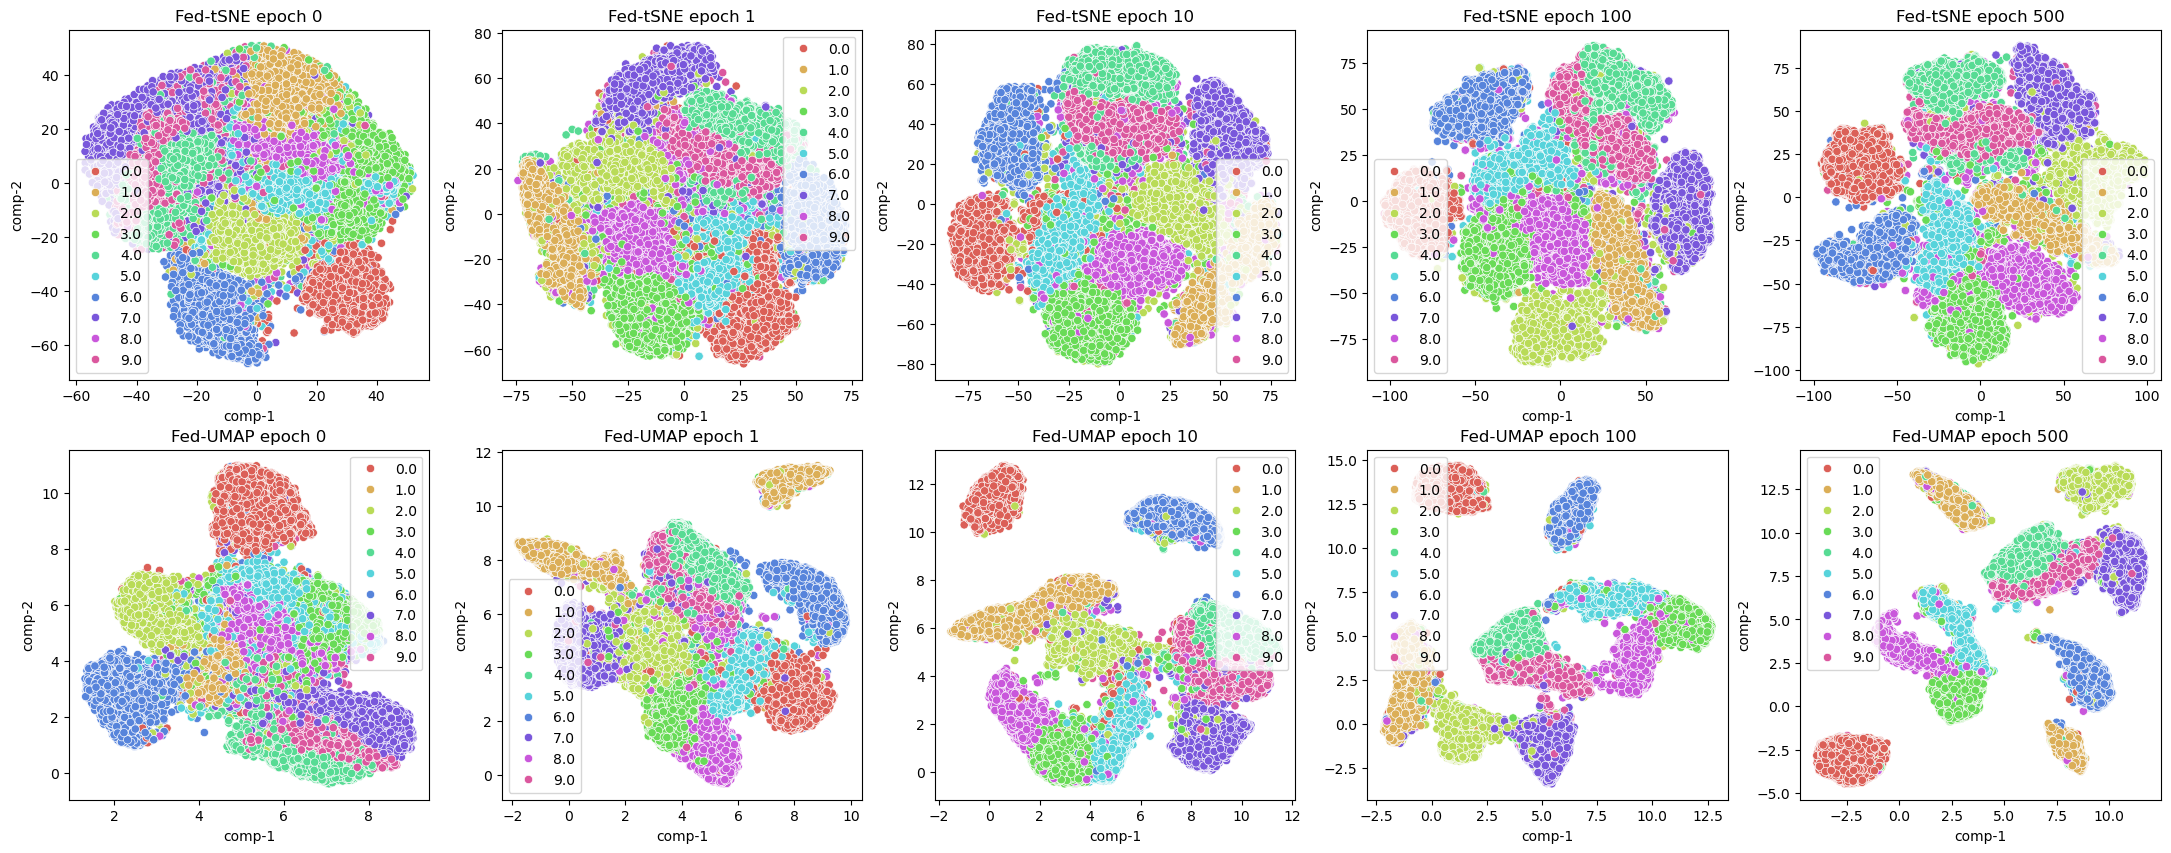

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(27, 10))

# <TSNE>
epoch_diff = [1, 2, 9, 90, 400]
real_epoch = [0, 1, 10, 100, 500]
loss_list = []
result =[]

Y = torch.rand((m, ny), dtype=torch.float32, requires_grad=True, device=device)

# init------------------------
distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
res, z = tsne_res(shuffled_X_cat.t(), distance, y_train)
Yi, loss = approximate_Y(Y, beta = 0.0, num_epochs = 1)
del Yi
loss_list.append(loss)
print('res:', res)
print('loss:', loss)

df = pd.DataFrame()
df["y"] = y_train
df["comp-1"] = z[:,0]
df["comp-2"] = z[:,1]

sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[0, 0]).set(title="Fed-tSNE epoch 0")
    
print('finish')

for i in range(1, len(epoch_diff)):  #len(epoch_diff)

    Y, loss = approximate_Y(Y, beta = 0.0, num_epochs = epoch_diff[i])
    loss_list.append(loss)

    distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
    res, z = tsne_res(shuffled_X_cat.t(), distance, y_train)
    result.append(res)
    print('res:', res)
    print('loss:', loss)

    df = pd.DataFrame()
    df["y"] = y_train
    df["comp-1"] = z[:,0]
    df["comp-2"] = z[:,1]

    sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                        palette=sns.color_palette("hls", 10),
                        data=df, ax=axes[0, i]).set(title=f"Fed-tSNE epoch {real_epoch[i]}")
    
    print('finish')

CA_10nn = [sublist[0] for sublist in result]
NMI = [sublist[1] for sublist in result]
NPA_10nn = [sublist[2] for sublist in result]

print('tsne')
print('NMI:', NMI)
print('CA_10nn:', CA_10nn)
print('NPA_10nn', NPA_10nn)
print('loss_list', loss_list)

# ---------------------------------------------------------------------------------------
# <UMAP>
epoch_diff = [1, 2, 9, 90, 400]
real_epoch = [0, 1, 10, 100, 500]
loss_list = []
result =[]

Y = torch.rand((m, ny), dtype=torch.float32, requires_grad=True, device=device)

# init------------------------
distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
res, z = umap_res(shuffled_X_cat.t(), distance, y_train)
Yi, loss = approximate_Y(Y, beta = 0.0, num_epochs = 1)
del Yi
loss_list.append(loss)
print('res:', res)
print('loss:', loss)

df = pd.DataFrame()
df["y"] = y_train
df["comp-1"] = z[:,0]
df["comp-2"] = z[:,1]

sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                    palette=sns.color_palette("hls", 10),
                    data=df, ax=axes[1, 0]).set(title="Fed-UMAP epoch 0")
    
print('finish')

for i in range(1, len(epoch_diff)):  #len(epoch_diff)

    Y, loss = approximate_Y(Y, beta = 0.0, num_epochs = epoch_diff[i])
    loss_list.append(loss)

    distance = estimate_x_dist(shuffled_X_cat, Y).cpu().detach().numpy()
    res, z = umap_res(shuffled_X_cat.t(), distance, y_train)
    result.append(res)
    print('res:', res)
    print('loss:', loss)

    df = pd.DataFrame()
    df["y"] = y_train
    df["comp-1"] = z[:,0]
    df["comp-2"] = z[:,1]

    sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                        palette=sns.color_palette("hls", 10),
                        data=df, ax=axes[1, i]).set(title=f"Fed-UMAP epoch {real_epoch[i]}")
    
    print('finish')

CA_10nn = [sublist[0] for sublist in result]
NMI = [sublist[1] for sublist in result]
NPA_10nn = [sublist[2] for sublist in result]

print('umap')
print('NMI:', NMI)
print('CA_10nn:', CA_10nn)
print('NPA_10nn', NPA_10nn)
print('loss_list', loss_list)